# madpyplotter — matplotlib plotting example

Mirror of `plotting.ipynb` (holoviews) using the new `madpyplotter` module.

Uses the **tt20bdf** sequence fetched directly from GitLab (no local bdf-line checkout needed).

**Kernel:** use the `bdf-line` conda environment.

In [ ]:
%matplotlib widget

import pandas as pd
import numpy as np
import requests
from cpymad.madx import Madx

import madtools.madpyplotter as mpp
import madtools.madutils as mu
import madtools.madtracker as mt

SEQ_URL  = 'https://gitlab.cern.ch/acc-models/acc-models-tls/-/raw/post_ls3/sps_extraction/tt20bdf_unsplit/tt20bdf.seq'
INIT_URL = 'https://gitlab.cern.ch/acc-models/acc-models-tls/-/raw/main/sps_extraction/tt20t2/tt20_initial_conditions.inp'

In [ ]:
def clean_sequence(text):
    lines = [l for l in text.splitlines()
             if 'endp42' not in l and 'end_tt24' not in l]
    return '\n'.join(lines)

def init_madx():
    seq_text  = clean_sequence(requests.get(SEQ_URL).text)
    init_text = requests.get(INIT_URL).text

    madx = Madx(stdout=False)
    madx.input(init_text)
    madx.input(seq_text)
    madx.use(sequence='tt20bdf')
    madx.select(flag='twiss', column=[
        's', 'l', 'betx', 'bety', 'dx', 'dy', 'dpx', 'dpy',
        'alfx', 'alfy', 'mux', 'muy', 'angle', 'k1l', 'tilt',
        'apertype', 'aper_1', 'aper_2', 'keyword', 'name',
    ])
    return madx

madx  = init_madx()
twiss = madx.twiss(beta0='INITBETA0_TT20_instant_20mm_4um').dframe()
print(f'Twiss table: {len(twiss)} elements, s = 0 … {twiss.s.max():.1f} m')
twiss.head(3)

Twiss table: 608 elements, s = 0 … 1950.3 m


,name,keyword,s,betx,alfx,mux,bety,alfy,muy,x,...,sig61,sig62,sig63,sig64,sig65,sig66,n1,apertype,aper_1,aper_2
#s,tt20bdf$start:1,marker,0.0000,508.101921,-28.165460,0.000000,146.060149,-4.013703,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,circle,0.0,0.0
ejpt,ejpt:1,marker,0.0000,508.101921,-28.165460,0.000000,146.060149,-4.013703,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,circle,0.0,0.0
drift_0[0],drift_0:0,drift,10.5478,1276.190877,-44.654366,0.002085,243.764399,-5.249295,0.008901,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,none,0.0,0.0


## 1. Synoptic

Text(0.5, 1.02, 'TT20–BDF synoptic')

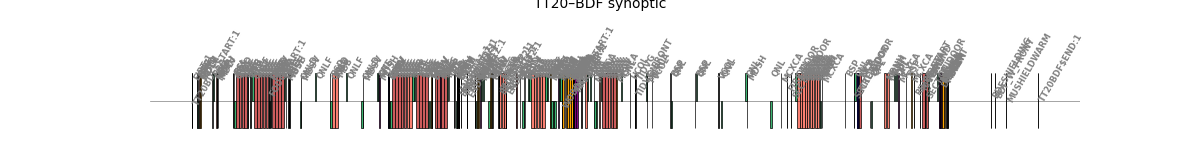

In [ ]:
fig, ax = mpp.plot_synoptic(twiss, show_names=True, show_markers=True)
fig.suptitle('TT20–BDF synoptic', y=1.02)

## 2. Twiss functions

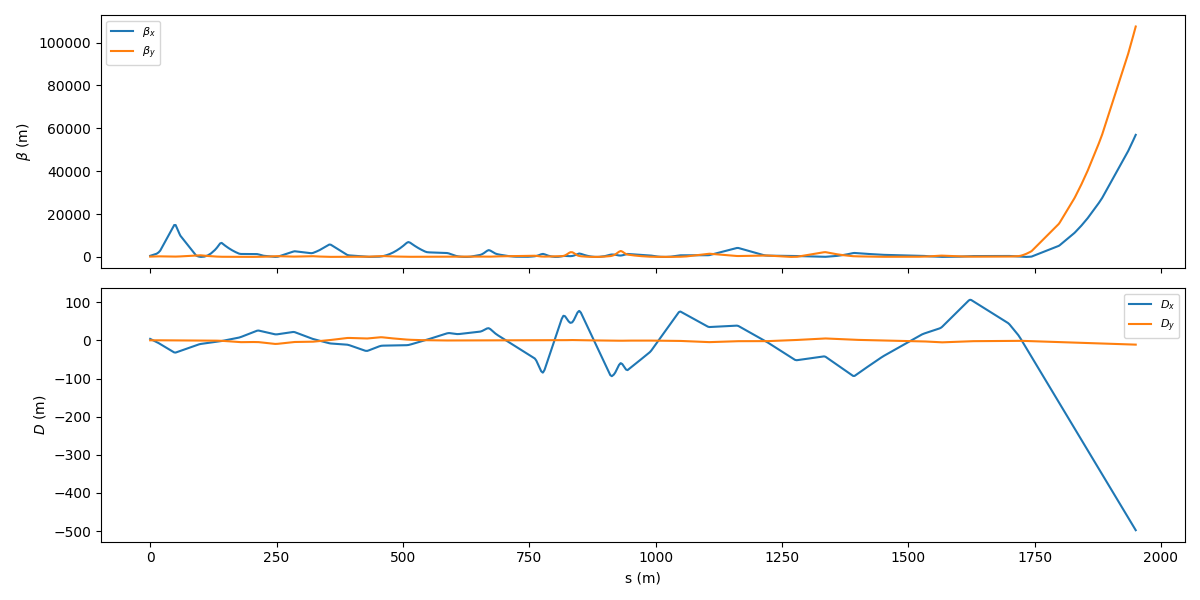

In [ ]:
fig, axes = mpp.plot_twiss(twiss, kind=['beta', 'd'])

## 3. Lattice (aperture blocks) — with range and Twiss sub-panels

Hover over an element to see its name, type, aperture, and k1l.

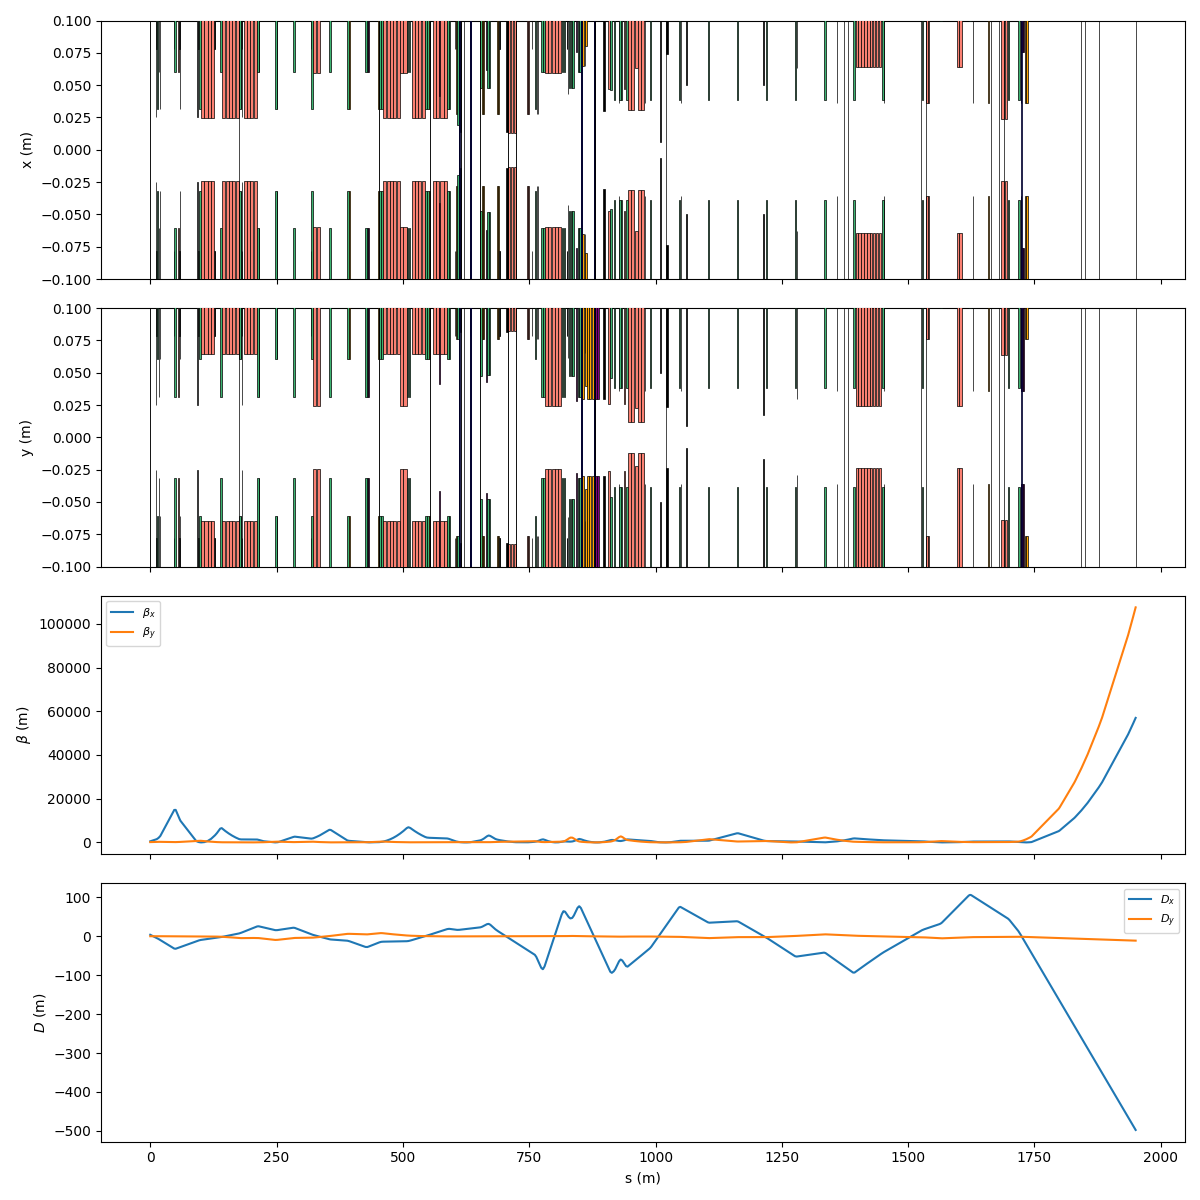

In [ ]:
fig, axes = mpp.plot_lattice(
    twiss,
    show_markers=True,
    twiss_plots=['beta', 'd'],
    ylim=(-0.1, 0.1),
)

## 4. Track beam and compute envelope

In [ ]:
madx = init_madx()

beam_split2 = pd.read_pickle('beam_split2.pkl')
beam_split2['pt'] = beam_split2['delta']
beam_split2['number'] = range(len(beam_split2))
beam_split2['t'] = 0

init_cond = mu.get_initial_condition(beam_split2)

beam_tracked, tw = mt.transfer_beam(
    madx, beam_split2, init_cond,
    sequence='tt20bdf', range_='#s/#e'
)
envelope = mu.calc_envelope(beam_tracked)
print(f'Tracked {len(beam_split2)} particles through {len(envelope)} locations')

ERROR: AD sub zero length vector
ERROR: AD sub zero length vector
ERROR: AD sub zero length vector
ERROR: AD sub zero length vector
ERROR: AD sub zero length vector
ERROR: AD sub zero length vector


Tracked 5000 particles through 608 locations


## 5. Envelope only

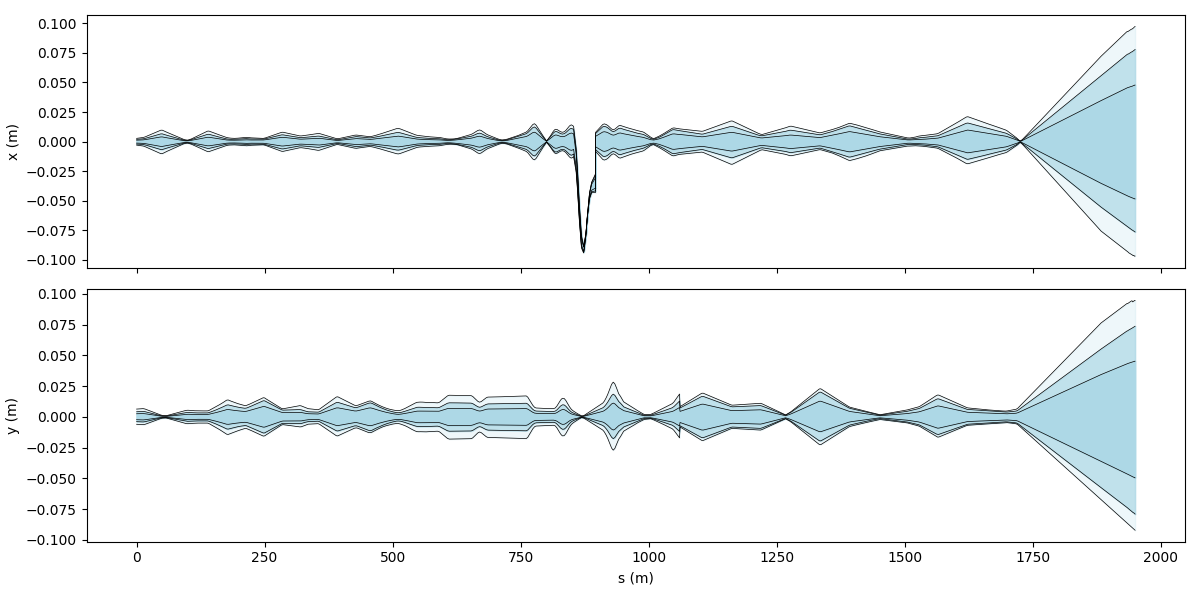

In [ ]:
fig, axes = mpp.plot_envelope(envelope)

## 6. Lattice + envelope combined (`plot_all`)

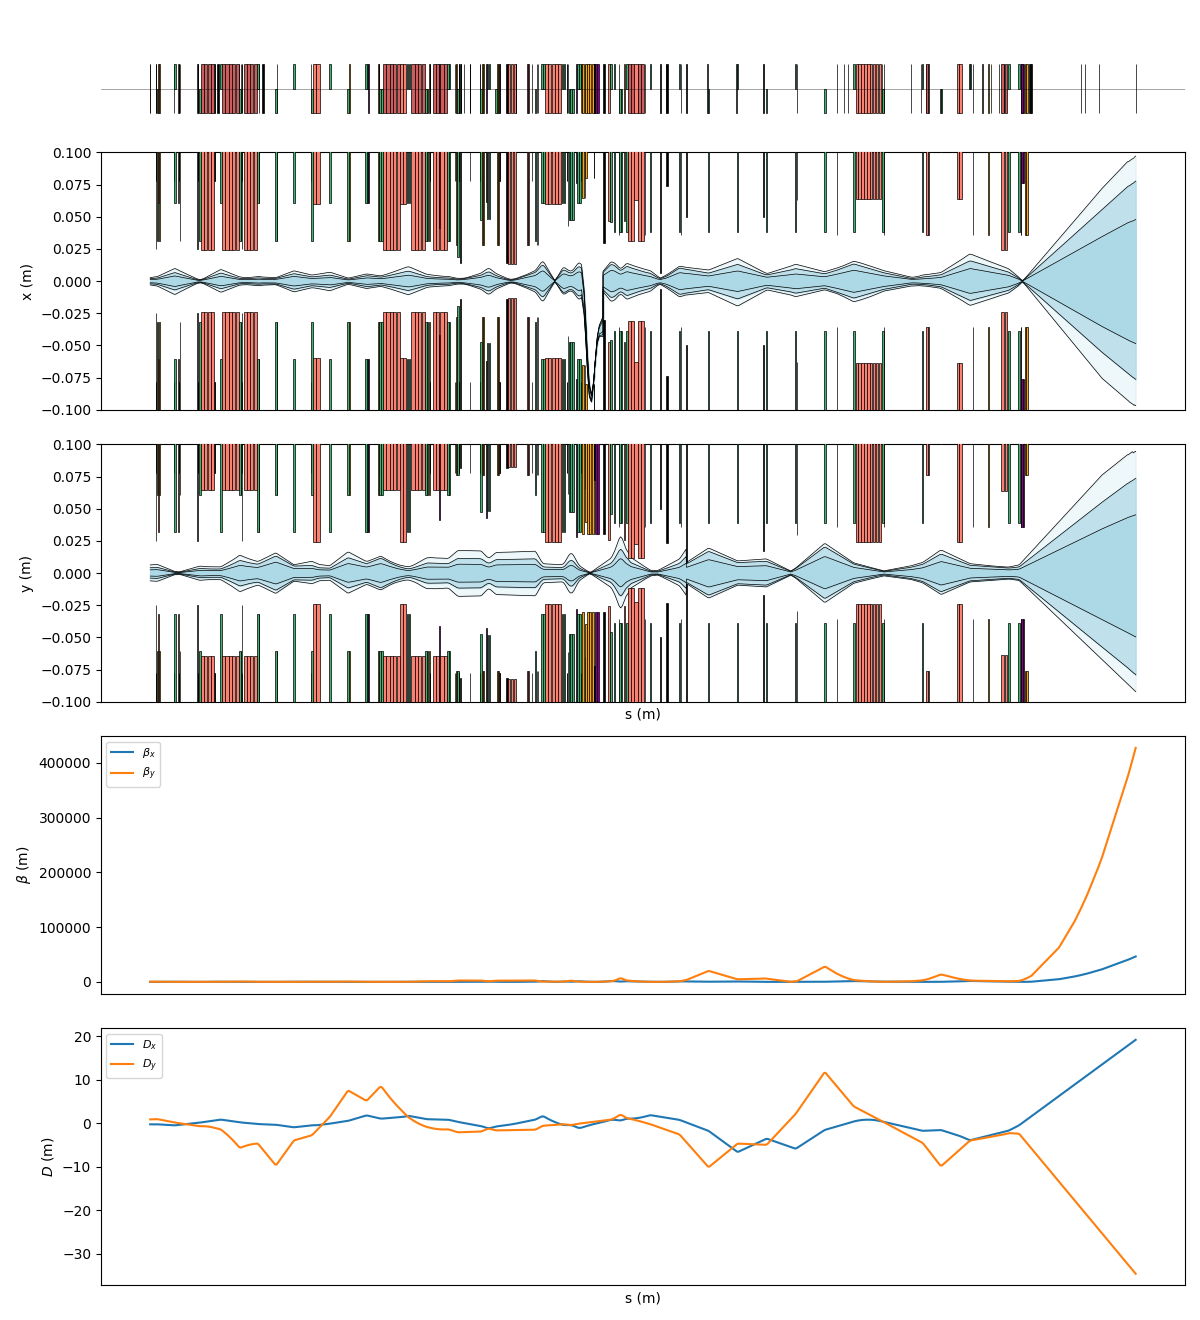

In [ ]:
fig, axes = mpp.plot_all(
    tw, envelope,
    twiss_plots=['beta', 'd'],
    synoptic=True,
    ylim=(-0.1, 0.1),
)

## 7. Beam within aperture at a specific location

Location: mbb.240439


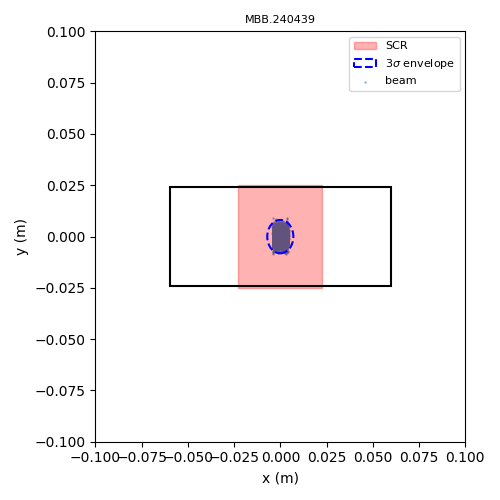

In [ ]:
# Pick a location that exists in both beam_tracked and twiss
loc = beam_tracked.index.get_level_values(0).unique()[len(beam_tracked.index.get_level_values(0).unique())//2]
print('Location:', loc)

fig, ax = mpp.plot_beam_within_aperture(beam_tracked, tw, loc)

## 8. Save to file

KeyboardInterrupt: 

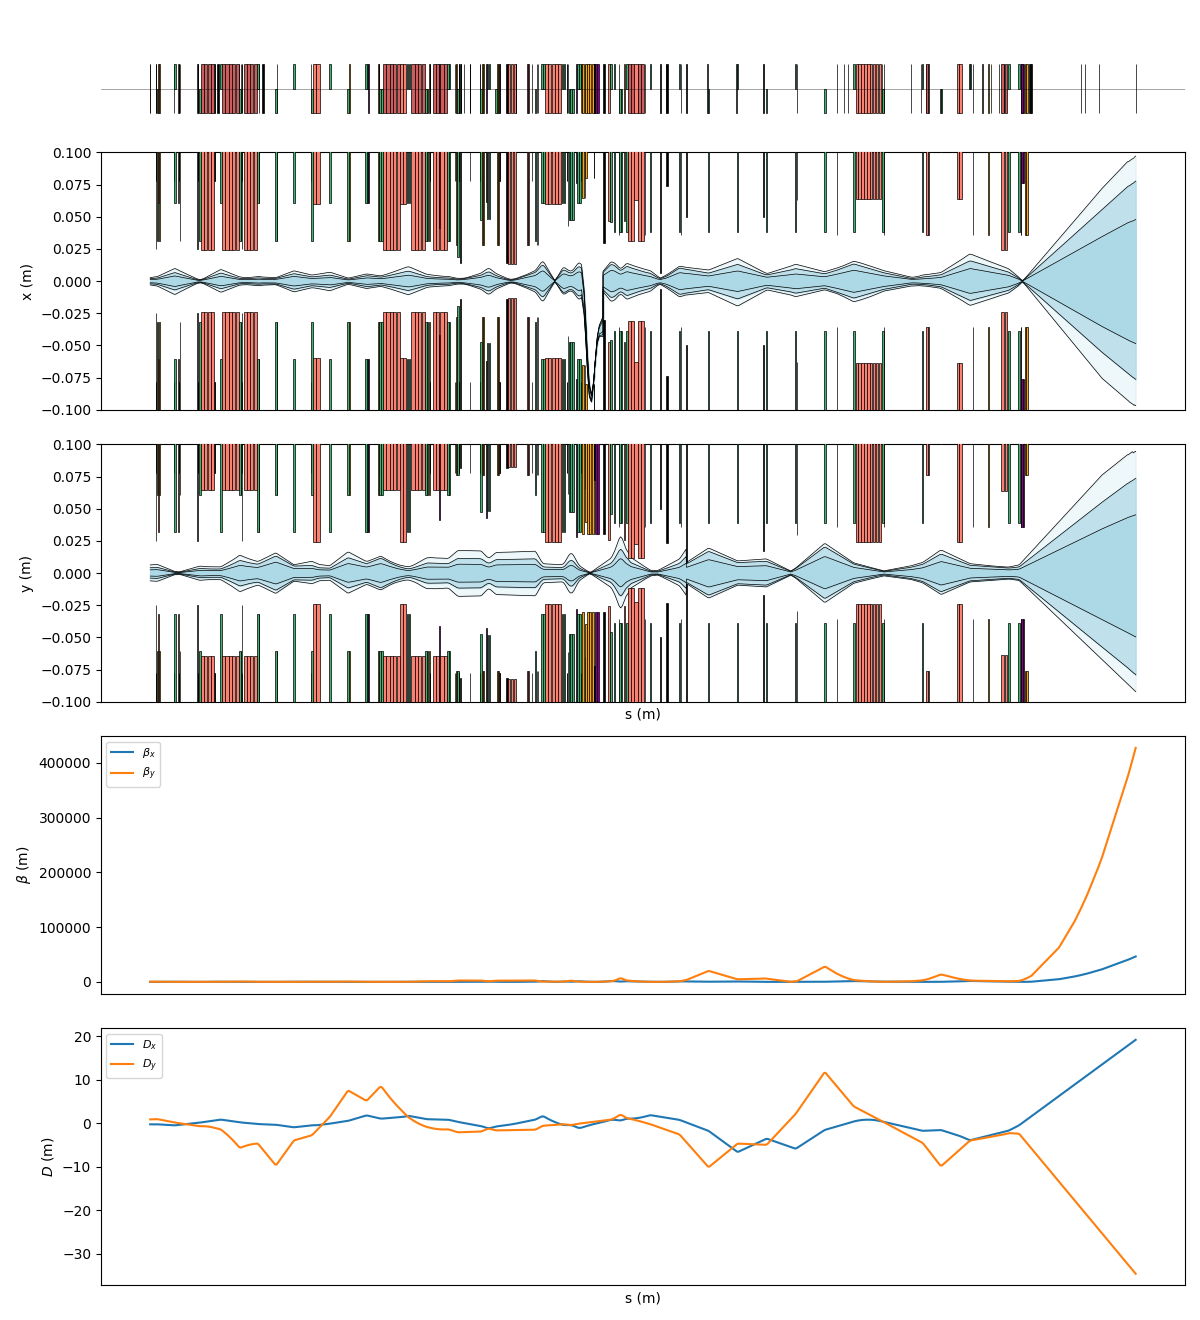

In [ ]:
fig, axes = mpp.plot_all(tw, envelope, twiss_plots=['beta', 'd'], synoptic=True, ylim=(-0.1, 0.1))
fig.savefig('lattice_and_env_mpl.png', dpi=150, bbox_inches='tight')
print('Saved lattice_and_env_mpl.png')